# Reading and Understanding the Data

1.Importig the data using pandas library

2.Understanding the structure of data

In [2]:
# importing reuired Libraries

import pandas as pd
import numpy as np 
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Read the provided CSV file 

ad = pd.read_csv(r"C:\Users\HP\Downloads\advertising (2).csv")
ad.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [4]:
ad.shape

(200, 4)

In [5]:
ad.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [6]:
ad.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


# Data visualization

In [7]:
# import required libraries

import matplotlib.pyplot as plt
import seaborn as sns

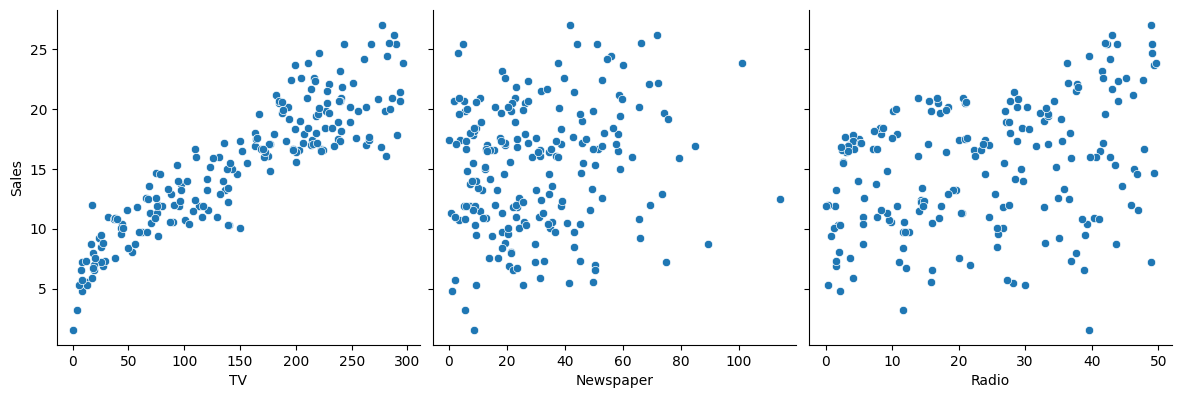

In [8]:
sns.pairplot(ad, x_vars=['TV', 'Newspaper', 'Radio'], y_vars='Sales',size=4, aspect=1, kind='scatter')
plt.show()

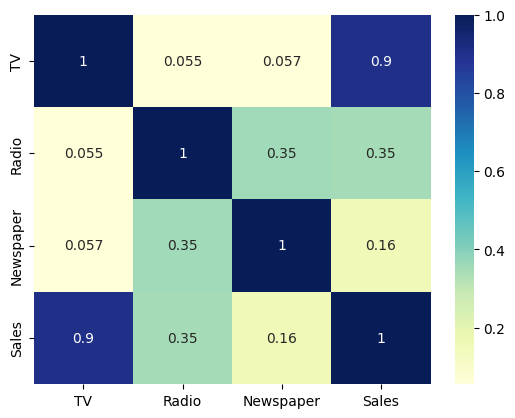

In [9]:
sns.heatmap(ad.corr(), cmap="YlGnBu", annot = True)
plt.show()

As we can see from the pairplot and the heatmap, the variable TV seems to be most correlated with Sales. Perform simple linear regression using TV as our feature variable.

# Simple Linear Regression Model

In [10]:
X = ad['TV']
y = ad['Sales']

- Train_Test_Split

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.7, test_size = 0.3, random_state = 100)

In [12]:
# Head of the train dataset

X_train.head()

74     213.4
3      151.5
185    205.0
26     142.9
90     134.3
Name: TV, dtype: float64

In [13]:
y_train.head()

74     17.0
3      16.5
185    22.6
26     15.0
90     14.0
Name: Sales, dtype: float64

# Building a Linear Model Using Statsmodel

In [14]:
import statsmodels.api as sm

By default, the statsmodels library fits a line on the dataset which passes through the origin. But in order to have an intercept, you need to manually use the add_constant then use OLS method to fit regression line

In [15]:
# add constant to get intercept
X_train_sm = sm.add_constant(X_train)

# Fit the regression line using "OLS"
lr = sm.OLS(y_train, X_train_sm).fit()

In [16]:
# print parameters of model
print(lr.params)

const    6.948683
TV       0.054546
dtype: float64


In [18]:
# print summary of model
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     611.2
Date:                Tue, 07 Apr 2026   Prob (F-statistic):           1.52e-52
Time:                        13:27:12   Log-Likelihood:                -321.12
No. Observations:                 140   AIC:                             646.2
Df Residuals:                     138   BIC:                             652.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.9487      0.385     18.068      0.0

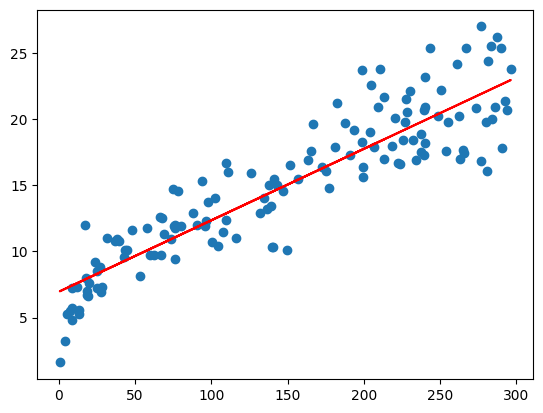

In [21]:
# Visualize the trained data with simple linear regression equation

plt.scatter(X_train, y_train)
plt.plot(X_train, 6.948 + 0.054*X_train, 'r')
plt.show()

# Residual Analysis

Distribution of the error terms

We need to check if the error terms are also normally distributed (which is infact, one of the major assumptions of linear regression), let us plot the histogram of the error terms and see what it looks like.

In [23]:
y_train_pred = lr.predict(X_train_sm)
res = (y_train - y_train_pred)

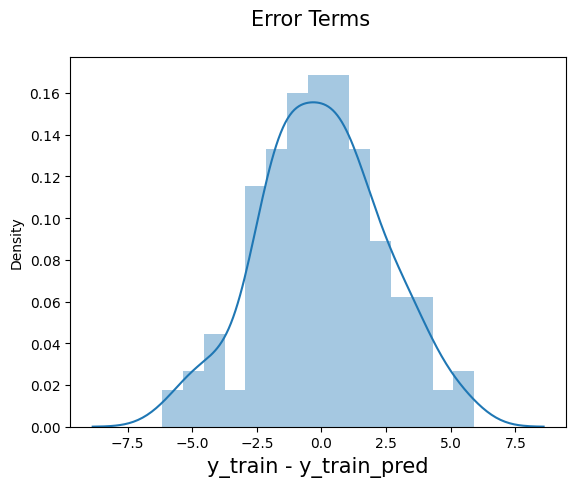

In [24]:
fig = plt.figure()
sns.distplot(res, bins = 15)
fig.suptitle('Error Terms', fontsize = 15)                  # Plot heading 
plt.xlabel('y_train - y_train_pred', fontsize = 15)         # X-label
plt.show()

The residuals are following the normally distributed with a mean 0. All good!

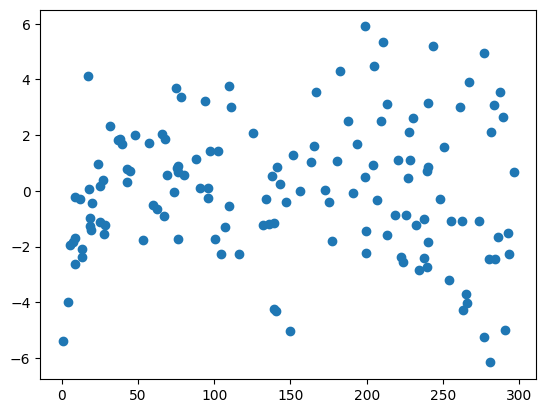

In [25]:
plt.scatter(X_train,res)
plt.show()

We are confident that the model fit isn't by chance, and has decent predictive power. The normality of residual terms allows some inference on the coefficients.

Although, the variance of residuals increasing with X indicates that there is significant variation that this model is unable to explain

# Predictions on Test Data

In [26]:
# Add a constant to X_test
X_test_sm = sm.add_constant(X_test)

# Predict the y values corresponding to X_test_sm
y_pred = lr.predict(X_test_sm)

In [27]:
y_pred.head()

126     7.374140
104    19.941482
99     14.323269
92     18.823294
111    20.132392
dtype: float64

In [28]:
# import libraries for metrics

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [29]:
#Returns the mean squared error; we'll take a square root
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(2.019296008966232)

Check the R-squared on the test set

In [30]:
r_squared = r2_score(y_test, y_pred)
r_squared

0.792103160124566

Visualizing the fit on the test set

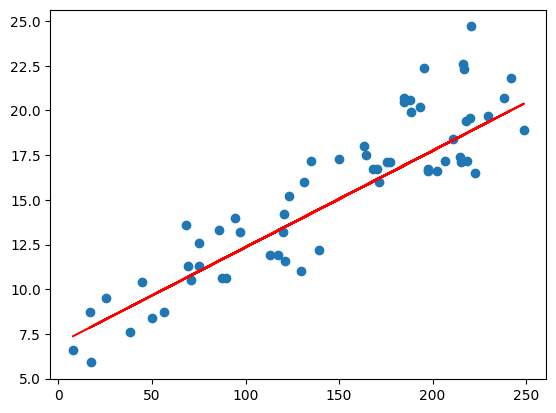

In [31]:
plt.scatter(X_test, y_test)
plt.plot(X_test, 6.948 + 0.054 * X_test, 'r')
plt.show()